# Inférence statistique

> Modèles retenus : CatBoost, XGBoost, LightGBM (cible `log1p`) + Stacking OOF  
> Optimisation sur **MAPE** (au lieu de MAE) + feature engineering ciblé sur les petites valeurs.

## Imports & configuration

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Manipulation de données
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import json


# Modèles
from sklearn.linear_model import LinearRegression

# Évaluation et validation
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)

from sklearn.inspection import permutation_importance

# Modèles de Gradient Boosting
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Optimisation d'hyperparamètres
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


import shap
from sklearn.base import BaseEstimator, RegressorMixin

from sklearn.impute import SimpleImputer
import lime
import lime.lime_tabular

# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.insert(0, os.path.abspath("../fonctions"))

%load_ext autoreload
%autoreload 

RANDOM_STATE = 1308

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### A.2 : Chargement des données

Split **temporel** : train 2020-2022 / val 2023 / test 2024. On entraîne toujours sur le passé et on évalue sur le futur.

In [3]:
# Chargement des données

df_train = pd.read_csv("../data_finale/featuring/train_featured.csv")
df_val   = pd.read_csv("../data_finale/featuring/val_featured.csv")
df_test  = pd.read_csv("../data_finale/featuring/test_featured.csv")
df_en_cours = pd.read_csv("../data_finale/featuring/en_cours_featured.csv")

# On supprime les lignes avec des valeurs manquantes pour notre variable cible

colonne_cible  = "market_value_in_eur"

df_train = df_train.dropna(subset=[colonne_cible])
df_val   = df_val.dropna(subset=[colonne_cible])
df_test  = df_test.dropna(subset=[colonne_cible])
df_en_cours = df_en_cours.dropna(subset=[colonne_cible])

In [4]:
# Colonnes à supprimer pour l'entraînement

colonne_joueur = "player"
colonne_team   = "team"
colonne_nation = "nation"

cols_a_supprimer = [colonne_cible, colonne_joueur, colonne_team, colonne_nation, "position"]

X_train = df_train.drop(columns=cols_a_supprimer)
y_train = df_train[colonne_cible]

X_val = df_val.drop(columns=cols_a_supprimer)
y_val = df_val[colonne_cible]

X_test = df_test.drop(columns=cols_a_supprimer)
y_test = df_test[colonne_cible]

X_en_cours = df_en_cours.drop(columns=cols_a_supprimer)
y_en_cours = df_en_cours[colonne_cible]

In [5]:
# Préparation pour certains modèles : sélection dynamique des colonnes sans aucun NaN
colonnes_sans_nan = X_train.columns[X_train.isna().sum() == 0].tolist()

print(f"Filtrage pour les modèles linéaires/SVR :")
print(f"{len(colonnes_sans_nan)} colonnes conservées sur {X_train.shape[1]}.")

X_train_sans_nan = X_train[colonnes_sans_nan]
X_val_sans_nan   = X_val[colonnes_sans_nan]
X_test_sans_nan  = X_test[colonnes_sans_nan]
X_en_cours_sans_nan = X_en_cours[colonnes_sans_nan]

Filtrage pour les modèles linéaires/SVR :
145 colonnes conservées sur 154.


### A.4 : Préparation des jeux de données X / y

In [6]:
cols_a_supprimer = [
    colonne_cible, colonne_joueur, colonne_team, colonne_nation,
    "position"
]

# On supprime uniquement les colonnes qui existent réellement

# On supprime (ou non) les colonnes normalisées
cols_a_supprimer = [c for c in cols_a_supprimer if c in df_train.columns]
colonnes_nor = [c for c in df_train.columns if c.endswith("_nor")]

df_train = df_train.drop(columns=colonnes_nor, errors="ignore")
df_val   = df_val.drop(columns=colonnes_nor, errors="ignore")
df_test  = df_test.drop(columns=colonnes_nor, errors="ignore")
df_en_cours = df_en_cours.drop(columns=colonnes_nor, errors="ignore")

# Construction des datasets d'entraînement, validation et test
X_train = df_train.drop(columns=cols_a_supprimer)
y_train = df_train[colonne_cible]

X_val   = df_val.drop(columns=cols_a_supprimer)
y_val   = df_val[colonne_cible]

X_test  = df_test.drop(columns=cols_a_supprimer)
y_test  = df_test[colonne_cible]

X_en_cours  = df_en_cours.drop(columns=cols_a_supprimer)
y_en_cours  = df_en_cours[colonne_cible]

# Cibles log
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)
y_en_cours_log  = np.log1p(y_en_cours)

# Poids d'entraînement : sur-pondère les petites valeurs pour améliorer le MAPE
sample_weights_train = 1 / np.log1p(y_train)
sample_weights_train = sample_weights_train / sample_weights_train.mean()

print(f"X_train : {X_train.shape} | X_val : {X_val.shape} | X_test : {X_test.shape}")

X_train : (7404, 146) | X_val : (2431, 146) | X_test : (1751, 146)


### B2 : Comparaison des algorithmes (cible log)

**Ce qu'on teste :** quel algorithme, tuné avec Optuna, donne les meilleures performances ?

**Modèles comparés :** Random Forest, Extra Trees, XGBoost, LightGBM, CatBoost, SVR et ElasticNet.

**Objectif Optuna :** RMSE log. On entraîne sur `log1p(y)` et on retransforme avec `expm1` pour les métriques.

**Ce qui varie ici :** l'algorithme.  
**Ce qui reste fixe :** pipeline Bloc A, objectif RMSE log, `N_TRIALS = 75`, `sample_weight = 1/log1p(y)`.


#### B2.7 — Construction des modèles finaux

In [7]:
with open("../modelisation/meilleurs_hyperparametres.json", "r") as f:
    params = json.load(f)

xgb_final = XGBRegressor(
    **params["XGBoost"],
    tree_method="hist", enable_categorical=True,
    objective="reg:squarederror",
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
lgbm_final = LGBMRegressor(
    **params["LightGBM"],
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
cat_final = CatBoostRegressor(
    **params["CatBoost"],
    bootstrap_type="Bernoulli",
    random_state=RANDOM_STATE, early_stopping_rounds=50, verbose=0
)

modeles_finaux = {
    "XGBoost (log)":   xgb_final,
    "LightGBM (log)":  lgbm_final,
    "CatBoost (log)":  cat_final,
}


def evaluer_log(nom, modele, X_tr, y_tr_log, X_ev, y_ev, w=None):
    fit_kwargs = {"sample_weight": w} if w is not None else {}
    if isinstance(modele, CatBoostRegressor):
        modele.fit(X_tr, y_tr_log, eval_set=(X_ev, np.log1p(y_ev)), verbose=False, **fit_kwargs)
    else:
        modele.fit(X_tr, y_tr_log, **fit_kwargs)
    preds = np.expm1(modele.predict(X_ev))
    mae   = mean_absolute_error(y_ev, preds)
    rmse  = np.sqrt(mean_squared_error(y_ev, preds))
    mape  = mean_absolute_percentage_error(y_ev, preds)
    r2    = r2_score(y_ev, preds)
    n, p  = len(y_ev), X_ev.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    print(f"  {nom:12s} | MAPE : {mape:.2%} | MAE : {mae:>12,.0f} € | R² : {r2:.4f} | R²adj : {r2_adj:.4f}")
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "R2 Ajusté": r2_adj}

print("Évaluation validation")
resultats_val = {}
for nom, modele in modeles_finaux.items():
    resultats_val[nom] = evaluer_log(nom, modele, X_train, y_train_log, X_val, y_val, w=sample_weights_train)

df_val_res = pd.DataFrame(resultats_val).T.sort_values("MAPE")
print("\nClassement validation (MAPE croissant) :")
print(df_val_res)

Évaluation validation
  XGBoost (log) | MAPE : 41.80% | MAE :    3,022,519 € | R² : 0.8957 | R²adj : 0.8890
  LightGBM (log) | MAPE : 42.60% | MAE :    3,101,819 € | R² : 0.8877 | R²adj : 0.8805
  CatBoost (log) | MAPE : 43.14% | MAE :    3,203,065 € | R² : 0.8792 | R²adj : 0.8715

Classement validation (MAPE croissant) :
                         MAE          RMSE      MAPE        R2  R2 Ajusté
XGBoost (log)   3.022519e+06  5.813211e+06  0.417998  0.895664   0.888994
LightGBM (log)  3.101819e+06  6.032272e+06  0.426016  0.887652   0.880471
CatBoost (log)  3.203065e+06  6.254052e+06  0.431383  0.879239   0.871520


In [8]:
print("Évaluation test")
resultats_test = {}
for nom, modele in modeles_finaux.items():
    resultats_test[nom] = evaluer_log(nom, modele, X_train, y_train_log, X_test, y_test, w=sample_weights_train)

df_test_res = pd.DataFrame(resultats_test).T.sort_values("MAPE")
print("\nClassement test (MAPE croissant) :")
print(df_test_res)

Évaluation test
  XGBoost (log) | MAPE : 39.67% | MAE :    3,222,725 € | R² : 0.8838 | R²adj : 0.8732
  LightGBM (log) | MAPE : 40.57% | MAE :    3,374,719 € | R² : 0.8778 | R²adj : 0.8666
  CatBoost (log) | MAPE : 40.90% | MAE :    3,495,888 € | R² : 0.8685 | R²adj : 0.8566

Classement test (MAPE croissant) :
                         MAE          RMSE      MAPE        R2  R2 Ajusté
XGBoost (log)   3.222725e+06  6.227329e+06  0.396725  0.883819   0.873244
LightGBM (log)  3.374719e+06  6.387559e+06  0.405730  0.877764   0.866637
CatBoost (log)  3.495888e+06  6.624713e+06  0.409011  0.868518   0.856551


In [9]:
print("Évaluation année en cours")
resultats_en_cours = {}
for nom, modele in modeles_finaux.items():
    resultats_en_cours[nom] = evaluer_log(nom, modele, X_train, y_train_log, X_en_cours, y_en_cours, w=sample_weights_train)

df_en_cours_res = pd.DataFrame(resultats_en_cours).T.sort_values("MAPE")
print("\nClassement en cours (MAPE croissant) :")
print(df_en_cours_res)

Évaluation année en cours
  XGBoost (log) | MAPE : 39.54% | MAE :    4,644,328 € | R² : 0.8046 | R²adj : 0.7819
  LightGBM (log) | MAPE : 40.38% | MAE :    4,678,831 € | R² : 0.8076 | R²adj : 0.7852
  CatBoost (log) | MAPE : 41.30% | MAE :    5,122,420 € | R² : 0.7642 | R²adj : 0.7368

Classement en cours (MAPE croissant) :
                         MAE          RMSE      MAPE        R2  R2 Ajusté
XGBoost (log)   4.644328e+06  8.819852e+06  0.395374  0.804591   0.781894
LightGBM (log)  4.678831e+06  8.752042e+06  0.403795  0.807584   0.785235
CatBoost (log)  5.122420e+06  9.688627e+06  0.413025  0.764199   0.736810


### B3 : Stacking OOF (XGBoost + LightGBM + CatBoost)

Le Stacking OOF combine les 3 meilleurs modèles boosting via un méta-modèle linéaire à coefficients positifs (combinaison convexe).

Les prédictions OOF garantissent que chaque exemple du train reçoit une prédiction issue d'un modèle qui ne l'a jamais vu, contrairement à un split fixe qui biaiserait les poids du méta-modèle.

#### B3.1 — Génération des prédictions OOF et construction du méta-modèle

In [10]:
base_models = ["XGBoost (log)", "LightGBM (log)", "CatBoost (log)"]

# Charger le JSON
with open("../modelisation/poids_stacking.json", "r") as f:
    meta_config = json.load(f)


meta = LinearRegression(positive=True)
# On réinjecte les poids
meta.coef_ = np.array([meta_config["weights"][nom] for nom in base_models])
meta.intercept_ = float(meta_config["intercept"])

print("Méta-modèle reconstruit avec succès !")
print("Poids :", dict(zip(base_models, meta.coef_.round(3))))
print(f"Intercept : {meta.intercept_:,.2f} €")

# Entraîner les modèles de base
print("\nEntraînement des modèles de base...")
for nom in base_models:
    modele = modeles_finaux[nom]
    if isinstance(modele, CatBoostRegressor):
        modele.fit(X_train, y_train_log, eval_set=(X_val, y_val_log),
                   sample_weight=sample_weights_train, verbose=False)
    else:
        modele.fit(X_train, y_train_log, sample_weight=sample_weights_train)
    print(f"  {nom} : entraîné")

# Prédictions sur Val et Test (repassées en Euros)
preds_val_euros = {nom: np.expm1(modeles_finaux[nom].predict(X_val)) for nom in base_models}
preds_test_euros = {nom: np.expm1(modeles_finaux[nom].predict(X_test)) for nom in base_models}
preds_en_cours_euros = {nom: np.expm1(modeles_finaux[nom].predict(X_en_cours)) for nom in base_models}

X_meta_val = pd.DataFrame(preds_val_euros)
X_meta_test = pd.DataFrame(preds_test_euros)
X_meta_en_cours = pd.DataFrame(preds_en_cours_euros)


pred_val_stack = meta.predict(X_meta_val)
pred_test_stack = meta.predict(X_meta_test)
pred_en_cours_stack = meta.predict(X_meta_en_cours)

preds_val_log  = {nom: modeles_finaux[nom].predict(X_val)  for nom in base_models}
preds_test_log = {nom: modeles_finaux[nom].predict(X_test) for nom in base_models}
preds_en_cours_log = {nom: modeles_finaux[nom].predict(X_en_cours) for nom in base_models}

print("\nPrédictions du Stacking calculées avec succès.")

Méta-modèle reconstruit avec succès !
Poids : {'XGBoost (log)': np.float64(0.77), 'LightGBM (log)': np.float64(0.102), 'CatBoost (log)': np.float64(0.184)}
Intercept : 422,249.15 €

Entraînement des modèles de base...
  XGBoost (log) : entraîné
  LightGBM (log) : entraîné
  CatBoost (log) : entraîné

Prédictions du Stacking calculées avec succès.


#### B3.2 — Comparaison Blend (moyenne) vs Stacking OOF

On compare deux stratégies d'assemblage :
- **Blend (moyenne simple)** : moyenne arithmétique des 3 prédictions : rapide mais sous-optimal
- **Stacking OOF** : méta-modèle linéaire à coefficients positifs : apprend les poids optimaux

In [11]:
# Blend 1 : moyenne simple
pred_val_moyenne  = X_meta_val.mean(axis=1)
pred_test_moyenne = X_meta_test.mean(axis=1)
pred_en_cours_moyenne = X_meta_en_cours.mean(axis=1)

print("Blend (moyenne simple)")
print(f"  Val  -> MAE : {mean_absolute_error(y_val, pred_val_moyenne):,.0f} € | R² : {r2_score(y_val, pred_val_moyenne):.4f}")
print(f"  Test -> MAE : {mean_absolute_error(y_test, pred_test_moyenne):,.0f} € | R² : {r2_score(y_test, pred_test_moyenne):.4f}")
print(f"  En cours -> MAE : {mean_absolute_error(y_en_cours, pred_en_cours_moyenne):,.0f} € | R² : {r2_score(y_en_cours, pred_en_cours_moyenne):.4f}")


# Moyenne simple (baseline de comparaison)
pred_val_moy  = X_meta_val.mean(axis=1)
pred_test_moy = X_meta_test.mean(axis=1)
pred_en_cours_moy = X_meta_en_cours.mean(axis=1)

print("\n=== Comparaison finale (Validation) ===")
for label, preds in [("Stacking OOF", pred_val_stack), ("Moyenne simple", pred_val_moy)]:
    print(f"  {label:15s} | MAPE : {mean_absolute_percentage_error(y_val, preds):.2%} | MAE : {mean_absolute_error(y_val, preds):>12,.0f} € | R² : {r2_score(y_val, preds):.4f}")

Blend (moyenne simple)
  Val  -> MAE : 3,025,678 € | R² : 0.8932
  Test -> MAE : 3,287,597 € | R² : 0.8829
  En cours -> MAE : 4,692,286 € | R² : 0.8015

=== Comparaison finale (Validation) ===
  Stacking OOF    | MAPE : 55.25% | MAE :    3,037,478 € | R² : 0.8988
  Moyenne simple  | MAPE : 41.95% | MAE :    3,025,678 € | R² : 0.8932


In [12]:
comparaison_blend = pd.DataFrame({
    "MAE Val": {
        "CatBoost (log) seul": mean_absolute_error(y_val,  np.expm1(modeles_finaux["CatBoost (log)"].predict(X_val))),
        "Blend (moyenne)":     mean_absolute_error(y_val,  pred_val_moyenne),
        "Blend (stacking OOF)":mean_absolute_error(y_val,  pred_val_stack),
    },
    "R2 Val": {
        "CatBoost (log) seul": r2_score(y_val,  np.expm1(modeles_finaux["CatBoost (log)"].predict(X_val))),
        "Blend (moyenne)":     r2_score(y_val,  pred_val_moyenne),
        "Blend (stacking OOF)":r2_score(y_val,  pred_val_stack),
    },
    "MAE Test": {
        "CatBoost (log) seul": mean_absolute_error(y_test, np.expm1(modeles_finaux["CatBoost (log)"].predict(X_test))),
        "Blend (moyenne)":     mean_absolute_error(y_test, pred_test_moyenne),
        "Blend (stacking OOF)":mean_absolute_error(y_test, pred_test_stack),
    },
    "R2 Test": {
        "CatBoost (log) seul": r2_score(y_test, np.expm1(modeles_finaux["CatBoost (log)"].predict(X_test))),
        "Blend (moyenne)":     r2_score(y_test, pred_test_moyenne),
        "Blend (stacking OOF)":r2_score(y_test, pred_test_stack),
    },
}).sort_values("MAE Test")

print(comparaison_blend)

                           MAE Val    R2 Val      MAE Test   R2 Test
Blend (moyenne)       3.025678e+06  0.893193  3.287597e+06  0.882878
Blend (stacking OOF)  3.037478e+06  0.898844  3.290929e+06  0.890506
CatBoost (log) seul   3.203065e+06  0.879239  3.490019e+06  0.869013


#### B3.3 — Analyse d'erreur par tranche de valeur

On décompose l'erreur du meilleur modèle par tranche de valeur marchande pour identifier où le modèle peine le plus.

In [13]:
meilleure_prediction_test = pred_test_stack

tranches       = [0, 5_000_000, 20_000_000, 50_000_000, np.inf]
labels_tranches= ["<5M€", "5-20M€", "20-50M€", ">50M€"]

df_erreur = pd.DataFrame({
    "y_reel": y_test.values,
    "y_pred": meilleure_prediction_test,
})
df_erreur["erreur_abs"] = (df_erreur["y_reel"] - df_erreur["y_pred"]).abs()
df_erreur["erreur_pct"] = df_erreur["erreur_abs"] / df_erreur["y_reel"]
df_erreur["tranche"]    = pd.cut(df_erreur["y_reel"], bins=tranches, labels=labels_tranches)

synthese_tranches = df_erreur.groupby("tranche", observed=True).agg(
    n_joueurs     =("y_reel",      "size"),
    valeur_moyenne=("y_reel",      "mean"),
    MAE           =("erreur_abs",  "mean"),
    MAPE          =("erreur_pct",  "mean"),
)
synthese_tranches["% du total joueurs"]          = synthese_tranches["n_joueurs"] / len(df_erreur) * 100
synthese_tranches["% de l'erreur absolue totale"]= (
    df_erreur.groupby("tranche", observed=True)["erreur_abs"].sum() / df_erreur["erreur_abs"].sum() * 100
)


print(synthese_tranches)

         n_joueurs  valeur_moyenne           MAE      MAPE  \
tranche                                                      
<5M€           817    2.413250e+06  1.041086e+06  0.828146   
5-20M€         586    1.178584e+07  3.508031e+06  0.308330   
20-50M€        285    3.222105e+07  6.513448e+06  0.207488   
>50M€           63    8.190476e+07  1.587000e+07  0.188635   

         % du total joueurs  % de l'erreur absolue totale  
tranche                                                    
<5M€              46.659052                     14.760602  
5-20M€            33.466591                     35.674378  
20-50M€           16.276413                     32.214486  
>50M€              3.597944                     17.350534  


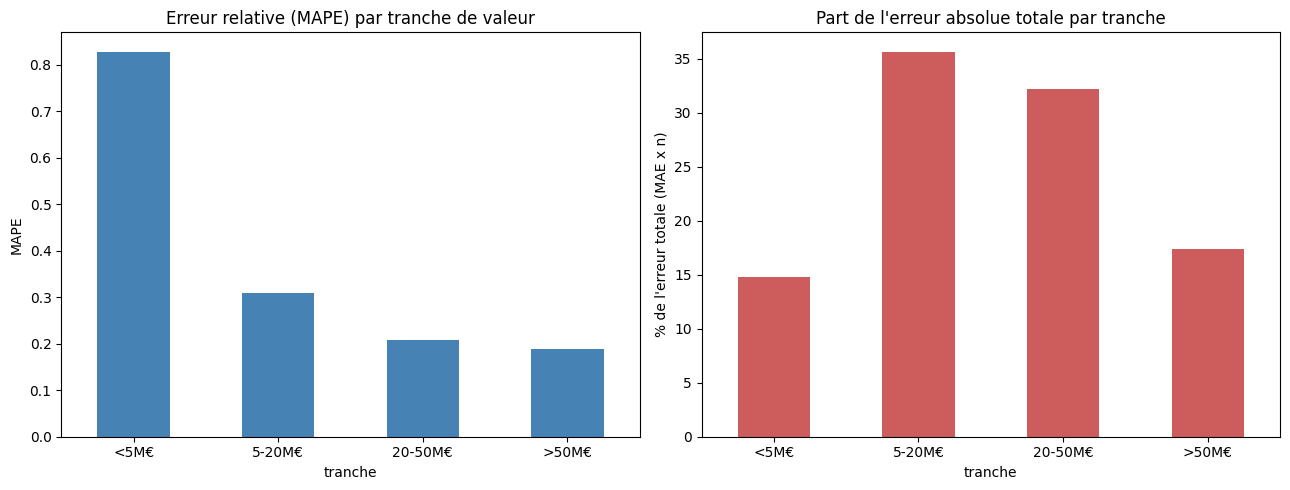

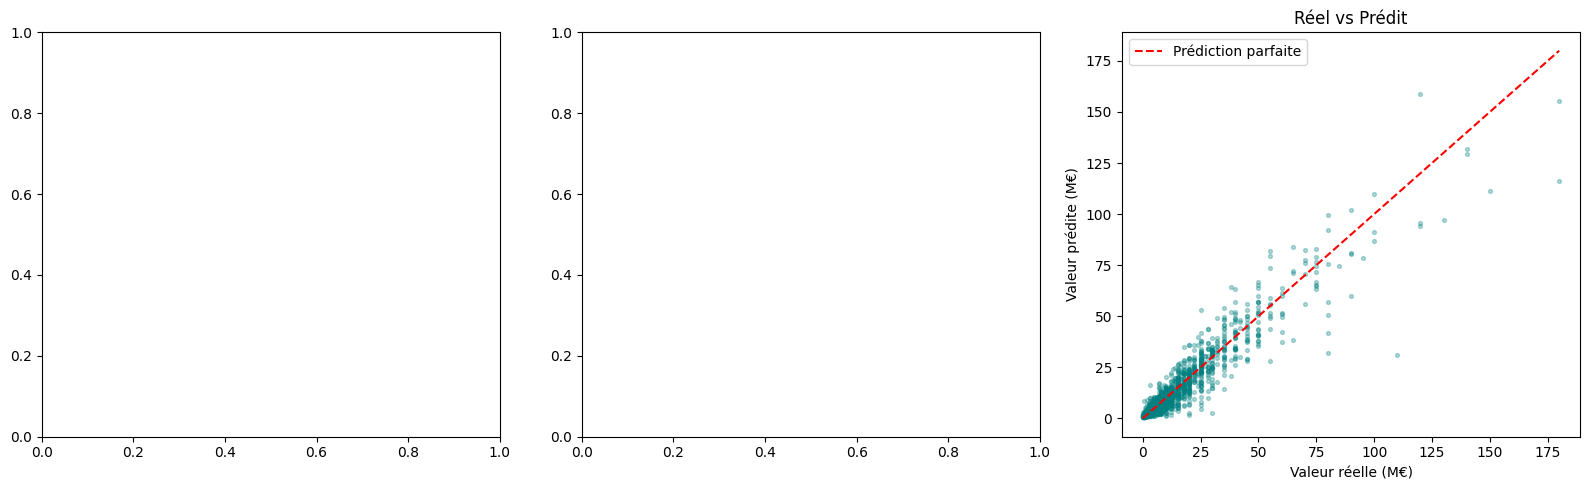

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

synthese_tranches["MAPE"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Erreur relative (MAPE) par tranche de valeur")
axes[0].set_ylabel("MAPE")
axes[0].tick_params(axis="x", rotation=0)

synthese_tranches["% de l'erreur absolue totale"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Part de l'erreur absolue totale par tranche")
axes[1].set_ylabel("% de l'erreur totale (MAE x n)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Valeurs réelles vs prédites
sample = df_erreur.sample(min(2000, len(df_erreur)), random_state=RANDOM_STATE)
axes[2].scatter(sample["y_reel"] / 1e6, sample["y_pred"] / 1e6, alpha=0.3, s=8, color="teal")
lim = max(sample["y_reel"].max(), sample["y_pred"].max()) / 1e6
axes[2].plot([0, lim], [0, lim], "r--", lw=1.5, label="Prédiction parfaite")
axes[2].set_xlabel("Valeur réelle (M€)")
axes[2].set_ylabel("Valeur prédite (M€)")
axes[2].set_title("Réel vs Prédit")
axes[2].legend()

plt.tight_layout()
plt.show()

#### B3.4 — Feature importance (CatBoost)

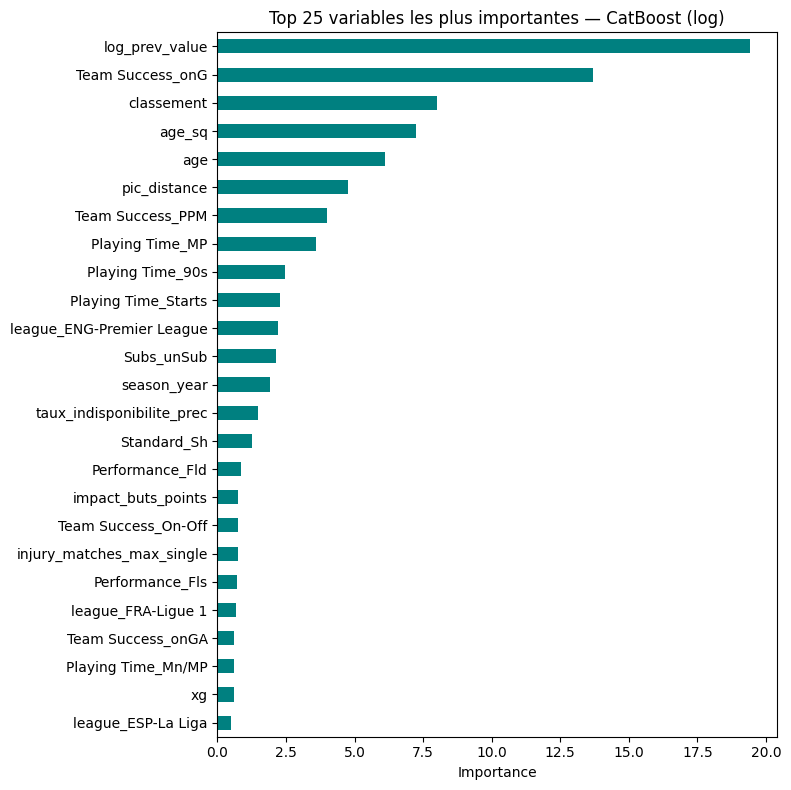

log_prev_value               19.427081
Team Success_onG             13.682868
classement                    8.019590
age_sq                        7.238953
age                           6.114823
pic_distance                  4.755920
Team Success_PPM              4.002661
Playing Time_MP               3.582968
Playing Time_90s              2.448508
Playing Time_Starts           2.277607
league_ENG-Premier League     2.206871
Subs_unSub                    2.127469
season_year                   1.898293
taux_indisponibilite_prec     1.472942
Standard_Sh                   1.265810
Performance_Fld               0.840777
impact_buts_points            0.746156
Team Success_On-Off           0.732434
injury_matches_max_single     0.730407
Performance_Fls               0.702132
league_FRA-Ligue 1            0.667269
Team Success_onGA             0.619968
Playing Time_Mn/MP            0.617720
xg                            0.611106
league_ESP-La Liga            0.489710
dtype: float64


In [15]:
importances = pd.Series(
    modeles_finaux["CatBoost (log)"].get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importances.head(25).sort_values().plot(kind="barh", color="teal")
plt.title("Top 25 variables les plus importantes — CatBoost (log)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances.head(25))

## Évaluation finale sur le TEST

> À lancer une seule fois, après avoir figé le choix du modèle sur la validation.

In [16]:
print("=== RÉSULTATS FINAUX (Test) ===")
resultats_test = {}
for label, preds in [
    ("Stacking OOF",  pred_test_stack),
    ("Moyenne simple",pred_test_moy),
    ("XGBoost seul",  np.expm1(preds_test_log["XGBoost (log)"])),
    ("LightGBM seul", np.expm1(preds_test_log["LightGBM (log)"])),
    ("CatBoost seul", np.expm1(preds_test_log["CatBoost (log)"])),
]:
    mae  = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    n, p = len(y_test), X_test.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    resultats_test[label] = {"MAPE": mape, "MAE": mae, "R2": r2, "R2 Ajusté": r2_adj}
    print(f"  {label:15s} | MAPE : {mape:.2%} | MAE : {mae:>12,.0f} € | R² : {r2:.4f}")

df_test_final = pd.DataFrame(resultats_test).T.sort_values("MAPE")
print("\nClassement final (MAPE croissant) :")
print(df_test_final)

# Modèle retenu
meilleure_prediction_test = pred_test_stack

=== RÉSULTATS FINAUX (Test) ===
  Stacking OOF    | MAPE : 53.02% | MAE :    3,290,929 € | R² : 0.8905
  Moyenne simple  | MAPE : 39.88% | MAE :    3,287,597 € | R² : 0.8829
  XGBoost seul    | MAPE : 39.67% | MAE :    3,222,725 € | R² : 0.8838
  LightGBM seul   | MAPE : 40.57% | MAE :    3,374,719 € | R² : 0.8778
  CatBoost seul   | MAPE : 40.92% | MAE :    3,490,019 € | R² : 0.8690

Classement final (MAPE croissant) :
                    MAPE           MAE        R2  R2 Ajusté
XGBoost seul    0.396725  3.222725e+06  0.883819   0.873244
Moyenne simple  0.398755  3.287597e+06  0.882878   0.872217
LightGBM seul   0.405730  3.374719e+06  0.877764   0.866637
CatBoost seul   0.409229  3.490019e+06  0.869013   0.857091
Stacking OOF    0.530151  3.290929e+06  0.890506   0.880539


In [17]:
print("=== RÉSULTATS FINAUX (Année en cours) ===")
resultats_en_cours = {}
for label, preds in [
    ("Stacking OOF",  pred_en_cours_stack),
    ("Moyenne simple",pred_en_cours_moy),
    ("XGBoost seul",  np.expm1(preds_en_cours_log["XGBoost (log)"])),
    ("LightGBM seul", np.expm1(preds_en_cours_log["LightGBM (log)"])),
    ("CatBoost seul", np.expm1(preds_en_cours_log["CatBoost (log)"])),
]:
    mae  = mean_absolute_error(y_en_cours, preds)
    mape = mean_absolute_percentage_error(y_en_cours, preds)
    r2   = r2_score(y_en_cours, preds)
    n, p = len(y_en_cours), X_en_cours.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    resultats_en_cours[label] = {"MAPE": mape, "MAE": mae, "R2": r2, "R2 Ajusté": r2_adj}
    print(f"  {label:15s} | MAPE : {mape:.2%} | MAE : {mae:>12,.0f} € | R² : {r2:.4f}")

df_en_cours_final = pd.DataFrame(resultats_en_cours).T.sort_values("MAPE")
print("\nClassement final (MAPE croissant) :")
print(df_en_cours_final)

# Modèle retenu
meilleure_prediction_en_cours = pred_en_cours_stack

=== RÉSULTATS FINAUX (Année en cours) ===
  Stacking OOF    | MAPE : 43.60% | MAE :    4,392,334 € | R² : 0.8247
  Moyenne simple  | MAPE : 39.83% | MAE :    4,692,286 € | R² : 0.8015
  XGBoost seul    | MAPE : 39.54% | MAE :    4,644,328 € | R² : 0.8046
  LightGBM seul   | MAPE : 40.38% | MAE :    4,678,831 € | R² : 0.8076
  CatBoost seul   | MAPE : 41.11% | MAE :    5,016,698 € | R² : 0.7741

Classement final (MAPE croissant) :
                    MAPE           MAE        R2  R2 Ajusté
XGBoost seul    0.395374  4.644328e+06  0.804591   0.781894
Moyenne simple  0.398276  4.692286e+06  0.801486   0.778429
LightGBM seul   0.403795  4.678831e+06  0.807584   0.785235
CatBoost seul   0.411082  5.016698e+06  0.774109   0.747872
Stacking OOF    0.435963  4.392334e+06  0.824670   0.804305


In [18]:
class StackingModel(BaseEstimator, RegressorMixin):

    def __init__(self, models, meta_model):
        self.models = models
        self.meta_model = meta_model

    def fit(self, X, y):
        # Pas besoin de réentraîner les modèles,
        # ils sont déjà entraînés dans ton notebook
        return self

    def predict(self, X):
        # Prédictions des modèles de niveau 1, repassées en euros (comme en cellule 17)
        X_meta = np.column_stack([
            np.expm1(model.predict(X)) for model in self.models
        ])

        # Le méta-modèle prédit directement en euros, pas besoin d'expm1 ensuite
        prediction_euros = self.meta_model.predict(X_meta)

        return prediction_euros



modele_stack = StackingModel(
    models=[
        modeles_finaux["XGBoost (log)"],
        modeles_finaux["LightGBM (log)"],
        modeles_finaux["CatBoost (log)"]
    ],
    meta_model=meta
)


print("--- PERMUTATION FEATURE IMPORTANCE ---")


result_perm = permutation_importance(
    modele_stack,
    X_val,
    y_val,
    scoring="r2",
    n_repeats=1,
    random_state=1308,
    n_jobs=-1
)


# Organisation des résultats
sorted_idx = result_perm.importances_mean.argsort()[::-1]


perm_importances = pd.DataFrame(
    {
        "Feature": X_val.columns[sorted_idx],
        "Importance_Mean": result_perm.importances_mean[sorted_idx],
        "Importance_Std": result_perm.importances_std[sorted_idx]
    }
)


print(perm_importances)

--- PERMUTATION FEATURE IMPORTANCE ---
                      Feature  Importance_Mean  Importance_Std
0              log_prev_value         0.378722             0.0
1            Team Success_onG         0.118326             0.0
2                         age         0.093353             0.0
3                  classement         0.054228             0.0
4                pic_distance         0.024034             0.0
..                        ...              ...             ...
141  sub_position_Centre-Back        -0.000334             0.0
142              Starts_Compl        -0.000673             0.0
143    injury_musculaire_nb_m        -0.000963             0.0
144                        xa        -0.001549             0.0
145                xg_buildup        -0.004317             0.0

[146 rows x 3 columns]


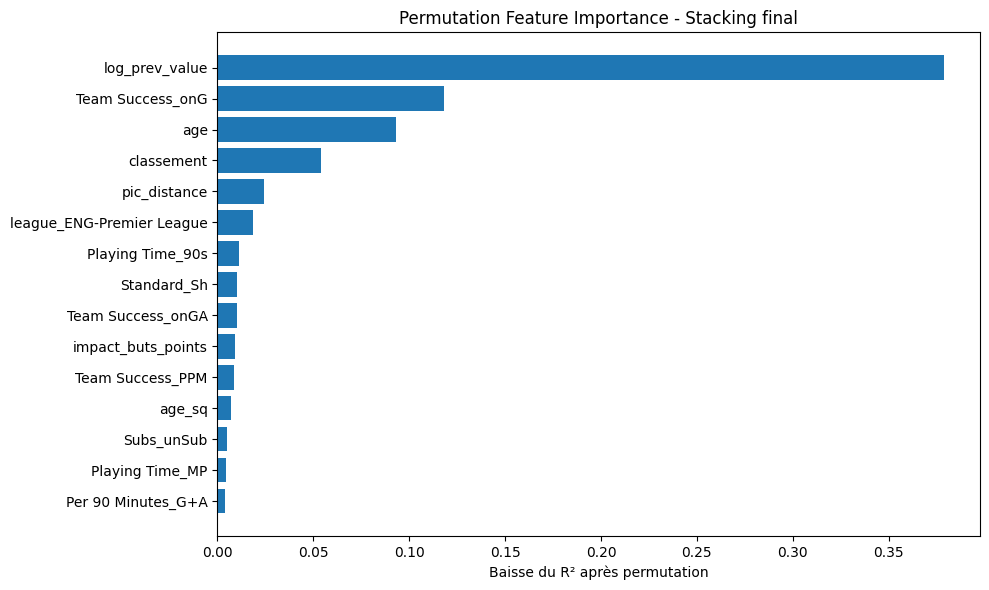

In [19]:
# Graphique
plt.figure(figsize=(10,6))

plt.barh(
    perm_importances["Feature"].head(15)[::-1],
    perm_importances["Importance_Mean"].head(15)[::-1],
    xerr=perm_importances["Importance_Std"].head(15)[::-1]
)

plt.xlabel("Baisse du R² après permutation")
plt.title("Permutation Feature Importance - Stacking final")
plt.tight_layout()
plt.show()

In [20]:
# print("Permutation Feature Importance par poste")

# # Liste des postes présents dans le jeu de validation
# postes = df_val["position"].dropna().unique().tolist()

# # Nombre minimum d'observations pour qu'un poste soit analysé (évite les postes anecdotiques)
# N_MIN_OBS = 30

# resultats_perm_par_poste = {}

# for poste in sorted(postes):
#     # Masque des lignes correspondant à ce poste (index aligné entre df_val, X_val, y_val)
#     mask = df_val["position"] == poste

#     if mask.sum() < N_MIN_OBS:
#         print(f"Poste '{poste}' ignoré ({mask.sum()} obs. < {N_MIN_OBS})")
#         continue

#     X_val_poste = X_val[mask.values]
#     y_val_poste = y_val[mask.values]

#     result_perm_poste = permutation_importance(
#         modele_stack,
#         X_val_poste,
#         y_val_poste,
#         scoring="neg_mean_absolute_percentage_error",
#         n_repeats=1,
#         random_state=1308,
#         n_jobs=-1
#     )

#     sorted_idx = result_perm_poste.importances_mean.argsort()[::-1]

#     perm_importances_poste = pd.DataFrame(
#         {
#             "Feature": X_val_poste.columns[sorted_idx],
#             "Importance_Mean": -result_perm_poste.importances_mean[sorted_idx],
#             "Importance_Std": result_perm_poste.importances_std[sorted_idx]
#         }
#     )

#     resultats_perm_par_poste[poste] = perm_importances_poste

#     print(f"\nPoste : {poste} (n={mask.sum()})")
#     print(perm_importances_poste.head(10))


# n_postes = len(resultats_perm_par_poste)
# fig, axes = plt.subplots(1, n_postes, figsize=(6 * n_postes, 6), sharex=False)

# if n_postes == 1:
#     axes = [axes]

# for ax, (poste, df_imp) in zip(axes, resultats_perm_par_poste.items()):
#     top = df_imp.head(10).iloc[::-1]
#     ax.barh(top["Feature"], top["Importance_Mean"], xerr=top["Importance_Std"], color="steelblue")
#     ax.set_title(f"Poste : {poste}")
#     ax.set_xlabel("Augmentation du MAPE après permutation")

# plt.tight_layout()
# plt.show()



Shap du stacking final


Background dataset has 2431 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2431 when initializing the masker.


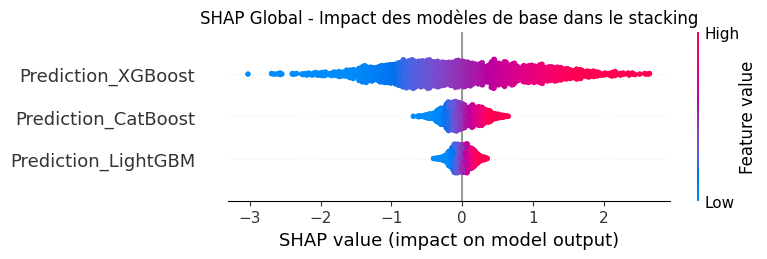

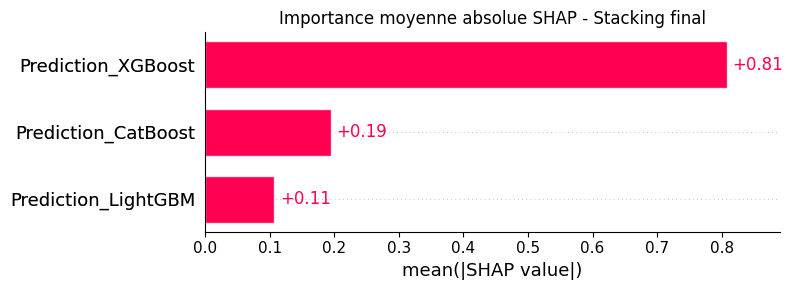


Explication locale de la première prédiction du jeu de validation


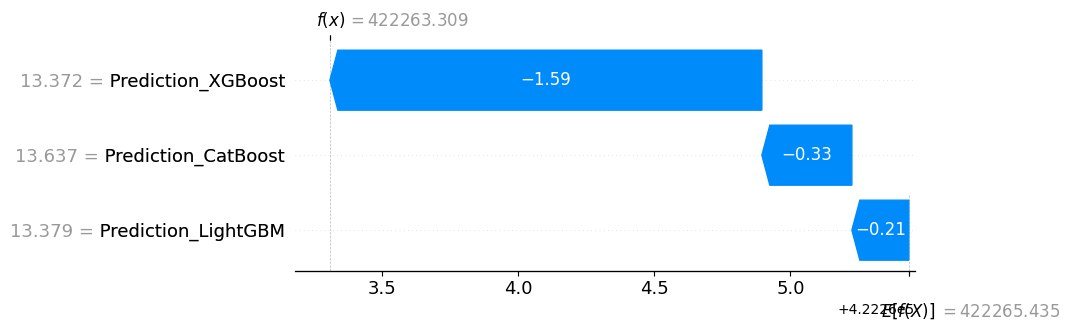

In [21]:
print("\nShap du stacking final")


# Le méta-modèle travaille sur les prédictions des modèles de base
X_meta_val = np.column_stack(
    [
        modeles_finaux["XGBoost (log)"].predict(X_val),
        modeles_finaux["LightGBM (log)"].predict(X_val),
        modeles_finaux["CatBoost (log)"].predict(X_val)
    ]
)


# Noms des variables du stacking
X_meta_val = pd.DataFrame(
    X_meta_val,
    columns=[
        "Prediction_XGBoost",
        "Prediction_LightGBM",
        "Prediction_CatBoost"
    ]
)


# Explainer adapté à LinearRegression
explainer = shap.LinearExplainer(
    meta,
    X_meta_val
)


shap_values = explainer(X_meta_val)



plt.figure(figsize=(10,6))

shap.plots.beeswarm(
    shap_values,
    max_display=10,
    show=False
)

plt.title(
    "SHAP Global - Impact des modèles de base dans le stacking"
)

plt.tight_layout()
plt.show()





plt.figure(figsize=(10,6))

shap.plots.bar(
    shap_values,
    max_display=10,
    show=False
)

plt.title(
    "Importance moyenne absolue SHAP - Stacking final"
)

plt.tight_layout()
plt.show()





print(
    "\nExplication locale de la première prédiction du jeu de validation"
)


shap.plots.waterfall(
    shap_values[0],
    max_display=10
)

In [22]:
def regrouper_shap(shap_values, groupes):
    """
    groupes : dict {"Nom affiché": ["col1", "col2", ...]}
    Additionne les valeurs SHAP des colonnes de chaque groupe en une seule variable.
    """
    feature_names = list(shap_values.feature_names)
    values = shap_values.values.copy()
    data = shap_values.data.copy()

    colonnes_groupees = [c for cols in groupes.values() for c in cols]
    colonnes_gardees = [c for c in feature_names if c not in colonnes_groupees]
    idx_gardees = [feature_names.index(c) for c in colonnes_gardees]

    nouvelles_values = values[:, idx_gardees]
    nouvelles_data   = data[:, idx_gardees]
    nouveaux_noms    = colonnes_gardees.copy()

    for nom_groupe, cols in groupes.items():
        idx_cols = [feature_names.index(c) for c in cols if c in feature_names]
        somme_values = values[:, idx_cols].sum(axis=1, keepdims=True)
        # On garde la valeur brute de la 1ère colonne du groupe pour l'affichage (ex: age brut)
        donnee_repr = data[:, idx_cols[0]:idx_cols[0]+1]

        nouvelles_values = np.hstack([nouvelles_values, somme_values])
        nouvelles_data   = np.hstack([nouvelles_data, donnee_repr])
        nouveaux_noms.append(nom_groupe)

    return shap.Explanation(
        values=nouvelles_values,
        base_values=shap_values.base_values,
        data=nouvelles_data,
        feature_names=nouveaux_noms
    )

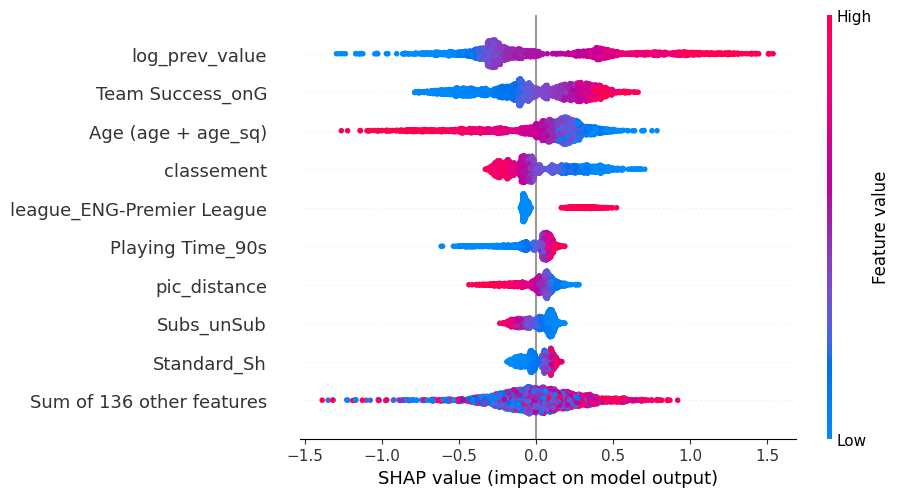

In [23]:
# Exemple sur XGBoost uniquement
explainer_xgb = shap.TreeExplainer(modeles_finaux["XGBoost (log)"])

shap_values_xgb = explainer_xgb(X_val)

groupes = {"Age (age + age_sq)": ["age", "age_sq"]}

shap_values_xgb_grouped = regrouper_shap(shap_values_xgb, groupes)

shap.plots.beeswarm(shap_values_xgb_grouped)

refaire le même avec barres et sous-cas (exemple donné par Thibault)

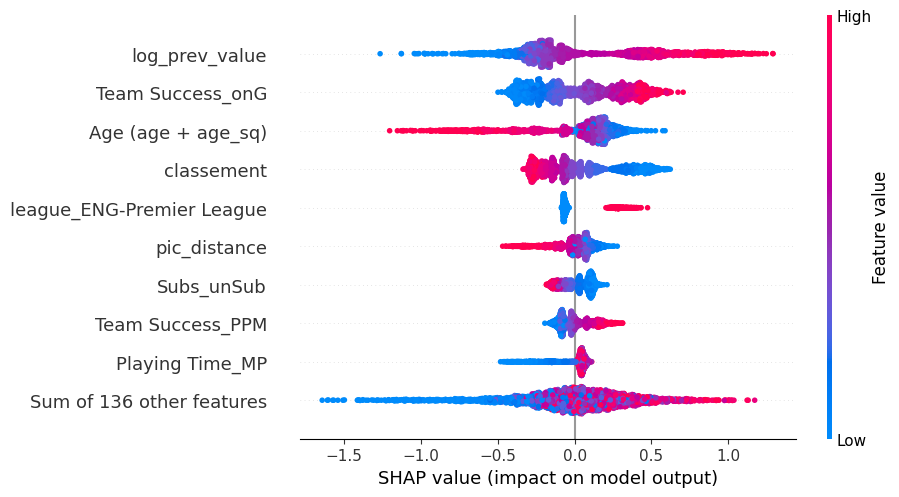

In [24]:
# Exemple sur CatBoost uniquement
explainer_cb = shap.TreeExplainer(modeles_finaux["CatBoost (log)"])
shap_values_cb = explainer_cb(X_val)

shap_values_cb_grouped = regrouper_shap(shap_values_cb, groupes)

shap.plots.beeswarm(shap_values_cb_grouped)

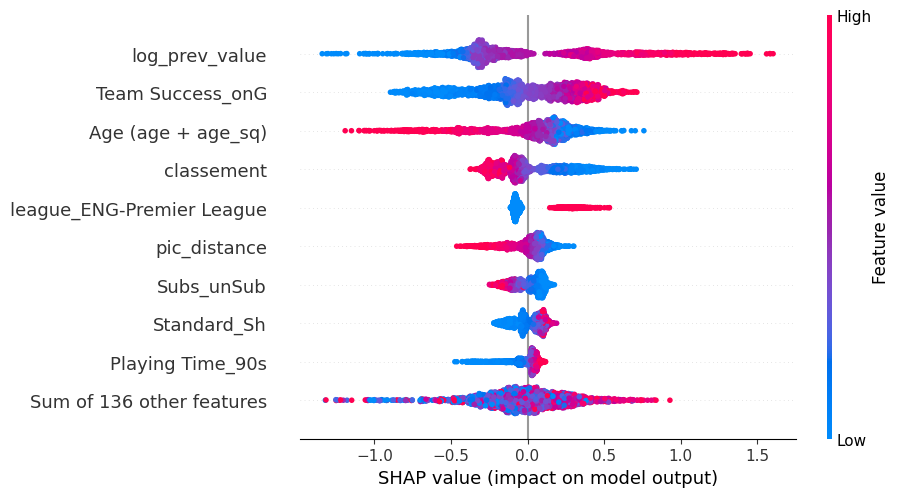

In [25]:
# Exemple sur LightGBM uniquement
explainer_lgb = shap.TreeExplainer(modeles_finaux["LightGBM (log)"])
shap_values_lgb = explainer_lgb(X_val)

shap_values_lgb_grouped = regrouper_shap(shap_values_lgb, groupes)

shap.plots.beeswarm(shap_values_lgb_grouped)

PermutationExplainer explainer: 2it [00:10, 10.27s/it]               


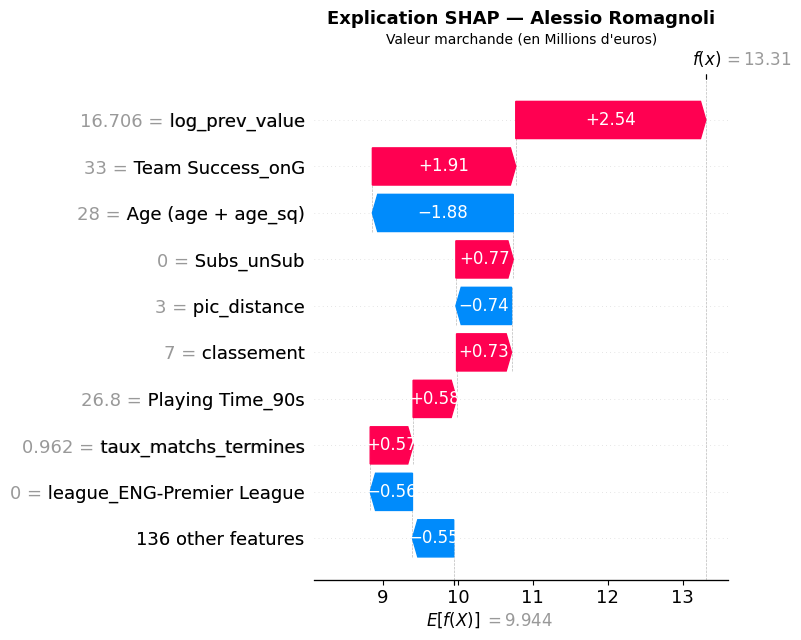

In [26]:
# Définition du modèle et des données
model_xgb = modeles_finaux["XGBoost (log)"]
indice_joueur = 90

# Récupérer le nom du joueur correspondant à l'indice choisi
nom_joueur = df_val[colonne_joueur].iloc[indice_joueur]

# Fonction wrapper qui prédit directement en Millions d'euros
def predict_m_euro(X):
    # Passe du log(Prix) à l'Euro, puis en Millions
    return np.exp(model_xgb.predict(X)) / 1_000_000

# Création de l'explicateur SHAP sur la vraie valeur (€)
# On utilise un échantillon de fond (ex: 100 lignes) pour calculer les références
background_data = shap.sample(X_val, 100)
explainer_m_euro = shap.Explainer(predict_m_euro, background_data)

# Calcul des valeurs SHAP pour le joueur choisi
shap_values_m_euro = explainer_m_euro(X_val.iloc[[indice_joueur]])

shap_values_m_euro_grouped = regrouper_shap(shap_values_m_euro, groupes)


# Affichage du waterfall
plt.figure(figsize=(9, 6))
shap.plots.waterfall(shap_values_m_euro_grouped[0], show=False)

plt.title(f"Explication SHAP — {nom_joueur}", fontsize=13, fontweight="bold")
plt.xlabel("Valeur marchande (en Millions d'euros)")
plt.tight_layout()
plt.show()

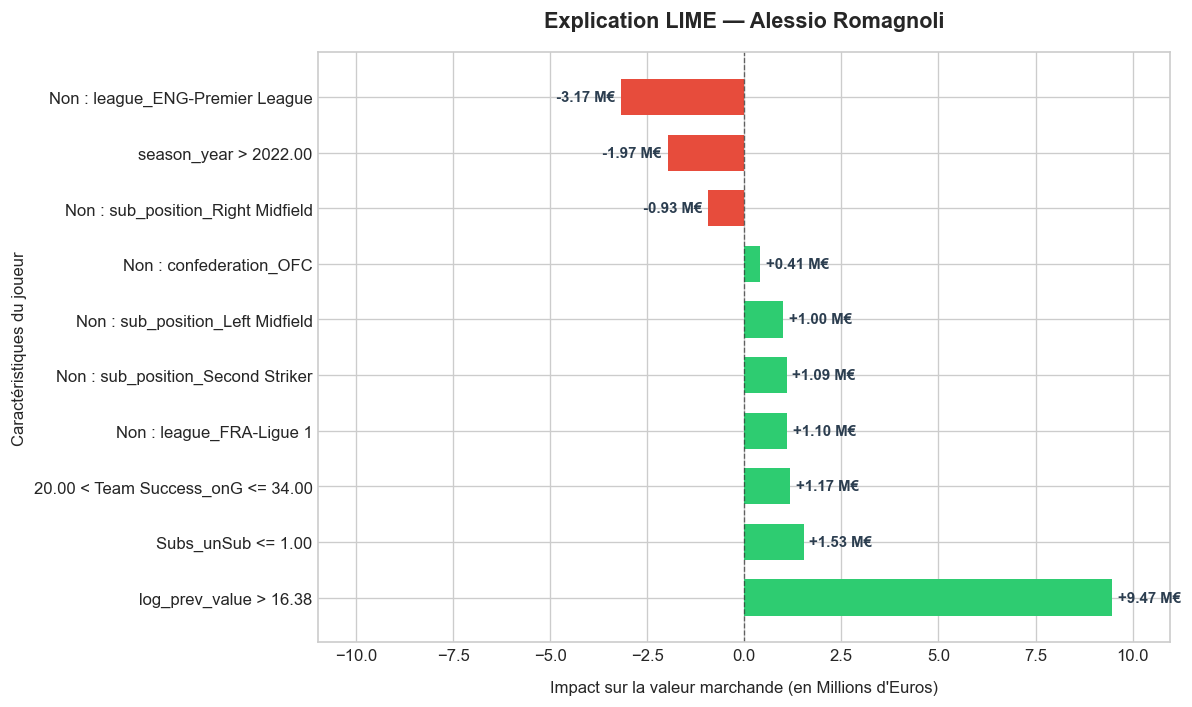

In [27]:
indice_joueur = 90

nom_joueur = df_val[colonne_joueur].iloc[indice_joueur]

model = modeles_finaux["XGBoost (log)"]

# Imputation des NaN pour LIME
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_val), columns=X_val.columns)

# Fonction de prédiction en Millions d'Euros
def predict_m_euro(X):
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=X_train.columns)
    log_preds = model.predict(X)
    return np.exp(log_preds) / 1_000_000

# Création de l'explicateur LIME
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_imputed),
    feature_names=list(X_train.columns),
    class_names=['Valeur_M_Euro'],
    mode='regression',
    random_state=42
)

# Extraction des données du joueur choisi
joueur_data = X_test_imputed.iloc[indice_joueur].values

# Calcul de l'explication LIME
exp = explainer.explain_instance(
    data_row=joueur_data,
    predict_fn=predict_m_euro,
    num_features=10
)



# Extraction des données
list_exp = exp.as_list()
df_lime = pd.DataFrame(list_exp, columns=['Feature_Condition', 'Impact'])
df_lime = df_lime.sort_values(by='Impact', ascending=False)

# Nettoyage des étiquettes
def clean_feature_label(condition):
    if "<= 0.00" in condition:
        feat = condition.replace(" <= 0.00", "")
        return f"Non : {feat}"
    elif "> 0.00" in condition:
        feat = condition.replace(" > 0.00", "")
        return f"Oui : {feat}"
    return condition

df_lime['Pretty_Label'] = df_lime['Feature_Condition'].apply(clean_feature_label)
df_lime['Color'] = df_lime['Impact'].apply(lambda x: '#2ecc71' if x > 0 else '#e74c3c')

# Création de la figure
plt.figure(figsize=(10, 6), dpi=120)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

bars = plt.barh(
    y=df_lime['Pretty_Label'], 
    width=df_lime['Impact'], 
    color=df_lime['Color'],
    edgecolor='none',
    height=0.65
)

plt.axvline(x=0, color='#333333', linestyle='--', linewidth=0.8, alpha=0.7)

# Textes au bout des barres
for bar in bars:
    width = bar.get_width()
    x_pos = width + (0.15 if width > 0 else -0.15)
    ha = 'left' if width > 0 else 'right'
    
    plt.text(
        x_pos, 
        bar.get_y() + bar.get_height()/2, 
        f"{width:+.2f} M€", 
        va='center', 
        ha=ha, 
        fontsize=9, 
        fontweight='bold',
        color='#2c3e50'
    )

# Titre et axes
plt.title(f"Explication LIME — {nom_joueur}", fontsize=13, pad=15, fontweight='bold')
plt.xlabel("Impact sur la valeur marchande (en Millions d'Euros)", fontsize=10, labelpad=10)
plt.ylabel("Caractéristiques du joueur", fontsize=10)

x_max = max(abs(df_lime['Impact'].min()), abs(df_lime['Impact'].max())) + 1.5
plt.xlim(-x_max, x_max)

plt.tight_layout()
plt.show()

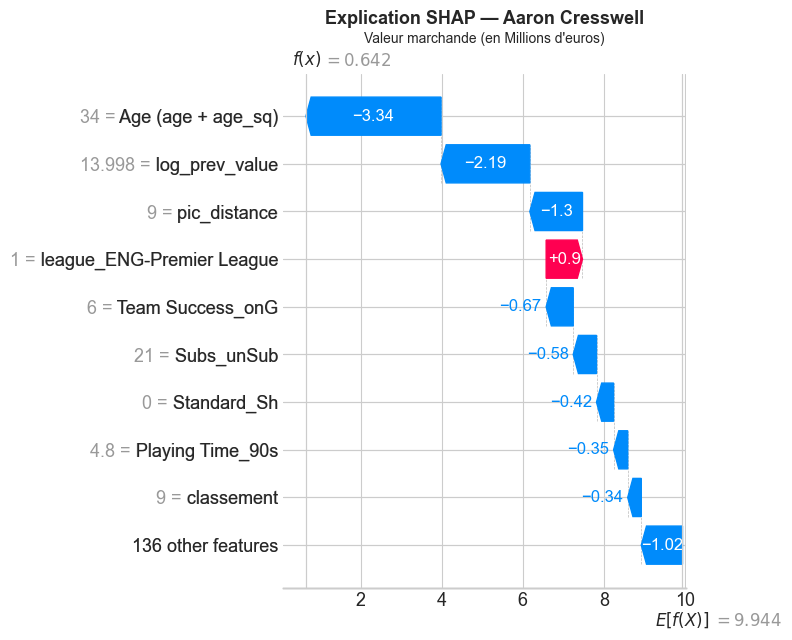

In [28]:
# Définition du modèle et des données
model_xgb = modeles_finaux["XGBoost (log)"]
indice_joueur = 0

# Récupérer le nom du joueur correspondant à l'indice choisi
nom_joueur = df_val[colonne_joueur].iloc[indice_joueur]


# Fonction wrapper qui prédit directement en Millions d'euros
def predict_m_euro(X):
    # Passe du log(Prix) à l'Euro, puis en Millions
    return np.exp(model_xgb.predict(X)) / 1_000_000

# Création de l'explicateur SHAP sur la vraie valeur (€)
# On utilise un échantillon de fond (ex: 100 lignes) pour calculer les références
background_data = shap.sample(X_val, 100)
explainer_m_euro = shap.Explainer(predict_m_euro, background_data)

# Calcul des valeurs SHAP pour le joueur choisi
shap_values_m_euro = explainer_m_euro(X_val.iloc[[indice_joueur]])

shap_values_m_euro_grouped = regrouper_shap(shap_values_m_euro, groupes)

# Affichage du waterfall
plt.figure(figsize=(9, 6))
shap.plots.waterfall(shap_values_m_euro_grouped[0], show=False)

plt.title(f"Explication SHAP — {nom_joueur}", fontsize=13, fontweight="bold")
plt.xlabel("Valeur marchande (en Millions d'euros)")
plt.tight_layout()
plt.show()

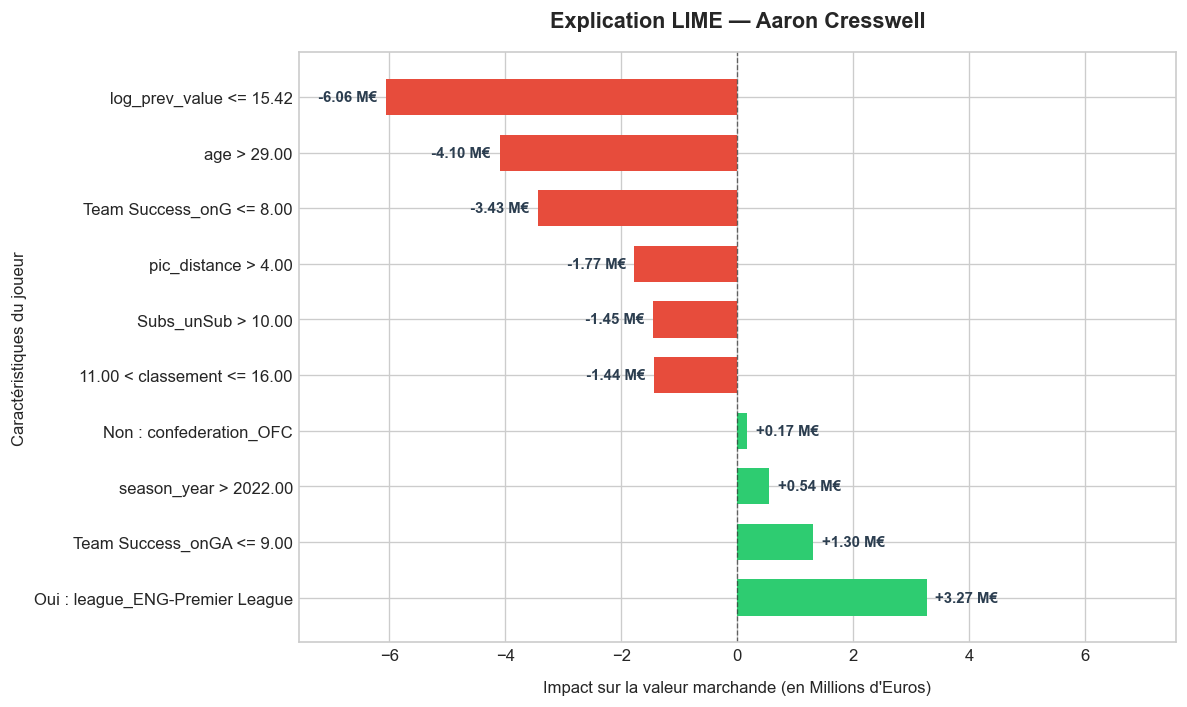

In [29]:
indice_joueur = 0

nom_joueur = df_test[colonne_joueur].iloc[indice_joueur]

model = modeles_finaux["XGBoost (log)"]

# Imputation des NaN pour LIME
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Fonction de prédiction en Millions d'Euros
def predict_m_euro(X):
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=X_train.columns)
    log_preds = model.predict(X)
    return np.exp(log_preds) / 1_000_000

# Création de l'explicateur LIME
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_imputed),
    feature_names=list(X_train.columns),
    class_names=['Valeur_M_Euro'],
    mode='regression',
    random_state=42
)

# Extraction des données du joueur choisi
joueur_data = X_test_imputed.iloc[indice_joueur].values

# Calcul de l'explication LIME
exp = explainer.explain_instance(
    data_row=joueur_data,
    predict_fn=predict_m_euro,
    num_features=10
)



# Extraction des données
list_exp = exp.as_list()
df_lime = pd.DataFrame(list_exp, columns=['Feature_Condition', 'Impact'])
df_lime = df_lime.sort_values(by='Impact', ascending=False)

# Nettoyage des étiquettes
def clean_feature_label(condition):
    if "<= 0.00" in condition:
        feat = condition.replace(" <= 0.00", "")
        return f"Non : {feat}"
    elif "> 0.00" in condition:
        feat = condition.replace(" > 0.00", "")
        return f"Oui : {feat}"
    return condition

df_lime['Pretty_Label'] = df_lime['Feature_Condition'].apply(clean_feature_label)
df_lime['Color'] = df_lime['Impact'].apply(lambda x: '#2ecc71' if x > 0 else '#e74c3c')

# Création de la figure
plt.figure(figsize=(10, 6), dpi=120)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

bars = plt.barh(
    y=df_lime['Pretty_Label'], 
    width=df_lime['Impact'], 
    color=df_lime['Color'],
    edgecolor='none',
    height=0.65
)

plt.axvline(x=0, color='#333333', linestyle='--', linewidth=0.8, alpha=0.7)

# Textes au bout des barres
for bar in bars:
    width = bar.get_width()
    x_pos = width + (0.15 if width > 0 else -0.15)
    ha = 'left' if width > 0 else 'right'
    
    plt.text(
        x_pos, 
        bar.get_y() + bar.get_height()/2, 
        f"{width:+.2f} M€", 
        va='center', 
        ha=ha, 
        fontsize=9, 
        fontweight='bold',
        color='#2c3e50'
    )

# Titre et axes
plt.title(f"Explication LIME — {nom_joueur}", fontsize=13, pad=15, fontweight='bold')
plt.xlabel("Impact sur la valeur marchande (en Millions d'Euros)", fontsize=10, labelpad=10)
plt.ylabel("Caractéristiques du joueur", fontsize=10)

x_max = max(abs(df_lime['Impact'].min()), abs(df_lime['Impact'].max())) + 1.5
plt.xlim(-x_max, x_max)

plt.tight_layout()
plt.show()